# Sensitivity Check: Nonnegative TCA on Speed-Corrected Residuals

This notebook diagnoses whether running nonnegative TCA (`ncp_hals`) on speed-corrected
residual tensors (which contain negative values) is appropriate, or whether a different
preprocessing strategy is needed.

**Diagnostics performed (for both BUFFER_TUNNEL and BUFFER_SOUND):**

1. Tensor statistics: fraction of negative entries, min/max/mean/std, histogram.
2. Reconstruction error comparison: `ncp_hals` vs `cp_als` on speed-corrected residuals.
3. Reconstruction error comparison: `ncp_hals` on residuals vs `ncp_hals` on per-neuron shifted residuals.
4. Automated diagnosis and recommendation.

Run on **one target file** to decide preprocessing before the full batch.

## 1. Imports, paths, load data (from Batch_TCA_Pipeline)

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# scipy.random shim for older tensortools
import scipy
if not hasattr(scipy, 'random'):
    import numpy.random
    scipy.random = numpy.random

import tensortools as tt

base = Path.cwd()
for p in [base, *base.parents]:
    if (p / 'data').exists():
        project_root = p
        break
else:
    project_root = base

data_root = str(project_root / 'data')
print(f"Data root: {data_root}")

Data root: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data


In [2]:
# Target identifiers
sup_bef = 'VR2_2021_03_20_1'
sup_aft = 'VR2_2021_04_06_1'
unsup_bef = 'TX105_2022_10_08_2'
unsup_aft = 'TX105_2022_10_19_2'

def get_beh_path(target_file):
    mapping = {
        sup_bef: 'Beh_sup_train1_before_learning.npy',
        sup_aft: 'Beh_sup_train1_after_learning.npy',
        unsup_bef: 'Beh_unsup_train1_before_learning.npy',
        unsup_aft: 'Beh_unsup_train1_after_learning.npy',
    }
    return mapping[target_file]

# Pick one target for this diagnostic
target_file = sup_bef

beh_path = os.path.join(data_root, get_beh_path(target_file))
spike_path = os.path.join(data_root, target_file + '_SVD_dec.npy')

svd_data = np.load(spike_path, allow_pickle=True).item()
spikes = (svd_data['U'].T @ svd_data['V']).T
del svd_data

beh_all = np.load(beh_path, allow_pickle=True).item()
beh = beh_all[target_file]
del beh_all

n_timepoints, n_neurons = spikes.shape
print(f"Target: {target_file}")
print(f"Spikes shape: {spikes.shape} = ({n_timepoints} timepoints x {n_neurons} neurons)")

Target: VR2_2021_03_20_1
Spikes shape: (24298, 81473) = (24298 timepoints x 81473 neurons)


## 2. Tensor construction and speed correction

In [3]:
BUFFER_TUNNEL = (2, 8)
BUFFER_SOUND = (5, 5)
SPEED_CORRECT_BY = "simple"
RANK_RANGE = range(1, 5)
REPLICATES = 3


def create_3d_matrix(trial_timestamps, buffer, spiking_data, spiking_timestamps):
    n_trials = len(trial_timestamps)
    n_time = buffer[0] + buffer[1] + 1
    n_neurons = spiking_data.shape[1]
    tensor = np.zeros((n_neurons, n_time, n_trials), dtype=np.float32)
    for index, timestamp in enumerate(trial_timestamps):
        idx = np.searchsorted(spiking_timestamps, timestamp, side='right')
        tensor[:, :, index] = spiking_data[idx - buffer[0] : idx + buffer[1] + 1, :].T
    return tensor


def create_speed_matrix(trial_timestamps, buffer, spiking_timestamps, run_speed):
    n_trials = len(trial_timestamps)
    n_time = buffer[0] + buffer[1] + 1
    idx = np.searchsorted(spiking_timestamps, trial_timestamps, side='right')
    speed_matrix = run_speed[np.arange(n_time)[:, None] + (idx - buffer[0])].astype(np.float32)
    return speed_matrix


def speed_correct_tensor(tensor, speed_matrix, n_neurons, n_time, n_trials, correct_by="simple"):
    n_obs = n_time * n_trials
    speed_flat = speed_matrix.ravel()
    intercept = np.ones((n_obs, 1), dtype=np.float64)
    speed_col = speed_flat.reshape(-1, 1)
    if correct_by == "simple":
        X = np.hstack([intercept, speed_col])
    elif correct_by == "bytrial":
        trial_idx = np.repeat(np.arange(n_trials), n_time)
        trial_dummies = (trial_idx[:, None] == np.arange(1, n_trials)).astype(np.float64)
        X = np.hstack([intercept, speed_col, trial_dummies])
    else:
        raise ValueError('correct_by must be "simple" or "bytrial"')
    Y = tensor.reshape(n_neurons, n_obs).T
    B = np.linalg.lstsq(X, Y, rcond=None)[0]
    residuals = (Y - X @ B).T.reshape(n_neurons, n_time, n_trials)
    return residuals.astype(np.float32)


def fit_ensemble(tensor, method, rank_range, replicates):
    """Fit a tensortools Ensemble across a rank sweep."""
    ensemble = tt.Ensemble(fit_method=method)
    ensemble.fit(tensor, ranks=rank_range, replicates=replicates)
    return ensemble


def best_objectives(ensemble, rank_range):
    """Extract the best (lowest) normalized objective per rank from an Ensemble."""
    return [min(ensemble.objectives(r)) for r in rank_range]

In [4]:
ft = beh['ft'][: spikes.shape[0] + 1]
run_speed = beh['ft_RunSpeed'][: len(ft)]

alignments = {
    'BUFFER_TUNNEL': {
        'timestamps': beh['Trial_start_time'],
        'buffer': BUFFER_TUNNEL,
    },
    'BUFFER_SOUND': {
        'timestamps': beh['SoundTime'],
        'buffer': BUFFER_SOUND,
    },
}

tensors = {}
for name, cfg in alignments.items():
    ts, buf = cfg['timestamps'], cfg['buffer']
    raw = create_3d_matrix(ts, buf, spikes, ft)
    sm = create_speed_matrix(ts, buf, ft, run_speed)
    nn, nt, nk = raw.shape
    residual = speed_correct_tensor(raw, sm, nn, nt, nk, correct_by=SPEED_CORRECT_BY)
    tensors[name] = {'raw': raw, 'residual': residual}
    print(f"{name}: shape {residual.shape}, raw min/max = {raw.min():.3f}/{raw.max():.3f}, "
          f"residual min/max = {residual.min():.3f}/{residual.max():.3f}")

BUFFER_TUNNEL: shape (81473, 11, 348), raw min/max = -5.080/63.255, residual min/max = -5.511/63.053
BUFFER_SOUND: shape (81473, 11, 348), raw min/max = -5.080/44.107, residual min/max = -5.034/43.759


## 3. Diagnostic 1 — Tensor negativity statistics

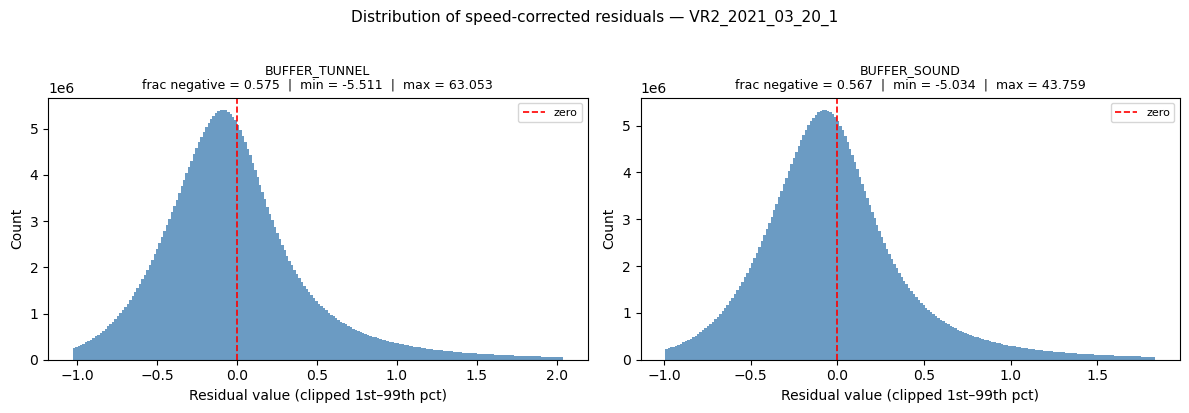


=== Negativity Summary ===

BUFFER_TUNNEL:
  shape: (81473, 11, 348)
  total_entries: 311878644
  n_negative: 179409212
  frac_negative: 0.5752532770406684
  min: -5.510797023773193
  max: 63.05315017700195
  mean: 4.3298641116962244e-08
  std: 0.5742462277412415
  median: -0.06800614297389984
  pct_1: -1.027707576751709
  pct_99: 2.039748191833496

BUFFER_SOUND:
  shape: (81473, 11, 348)
  total_entries: 311878644
  n_negative: 176700412
  frac_negative: 0.5665678474605654
  min: -5.033718585968018
  max: 43.7586784362793
  mean: -1.1579738057321265e-08
  std: 0.521018922328949
  median: -0.056009918451309204
  pct_1: -0.9930185675621033
  pct_99: 1.835326075553894


In [5]:
neg_stats = {}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, data) in zip(axes, tensors.items()):
    X = data['residual']
    total = X.size
    n_neg = int((X < 0).sum())
    frac_neg = n_neg / total
    stats = {
        'shape': X.shape,
        'total_entries': total,
        'n_negative': n_neg,
        'frac_negative': frac_neg,
        'min': float(X.min()),
        'max': float(X.max()),
        'mean': float(X.mean()),
        'std': float(X.std()),
        'median': float(np.median(X)),
        'pct_1': float(np.percentile(X, 1)),
        'pct_99': float(np.percentile(X, 99)),
    }
    neg_stats[name] = stats

    flat = X.ravel()
    clip_lo, clip_hi = stats['pct_1'], stats['pct_99']
    ax.hist(flat[(flat >= clip_lo) & (flat <= clip_hi)], bins=200, color='steelblue', edgecolor='none', alpha=0.8)
    ax.axvline(0, color='red', ls='--', lw=1.2, label='zero')
    ax.set_title(f"{name}\nfrac negative = {frac_neg:.3f}  |  min = {stats['min']:.3f}  |  max = {stats['max']:.3f}",
                 fontsize=9)
    ax.set_xlabel('Residual value (clipped 1st–99th pct)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

plt.suptitle(f"Distribution of speed-corrected residuals — {target_file}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== Negativity Summary ===")
for name, s in neg_stats.items():
    print(f"\n{name}:")
    for k, v in s.items():
        print(f"  {k}: {v}")

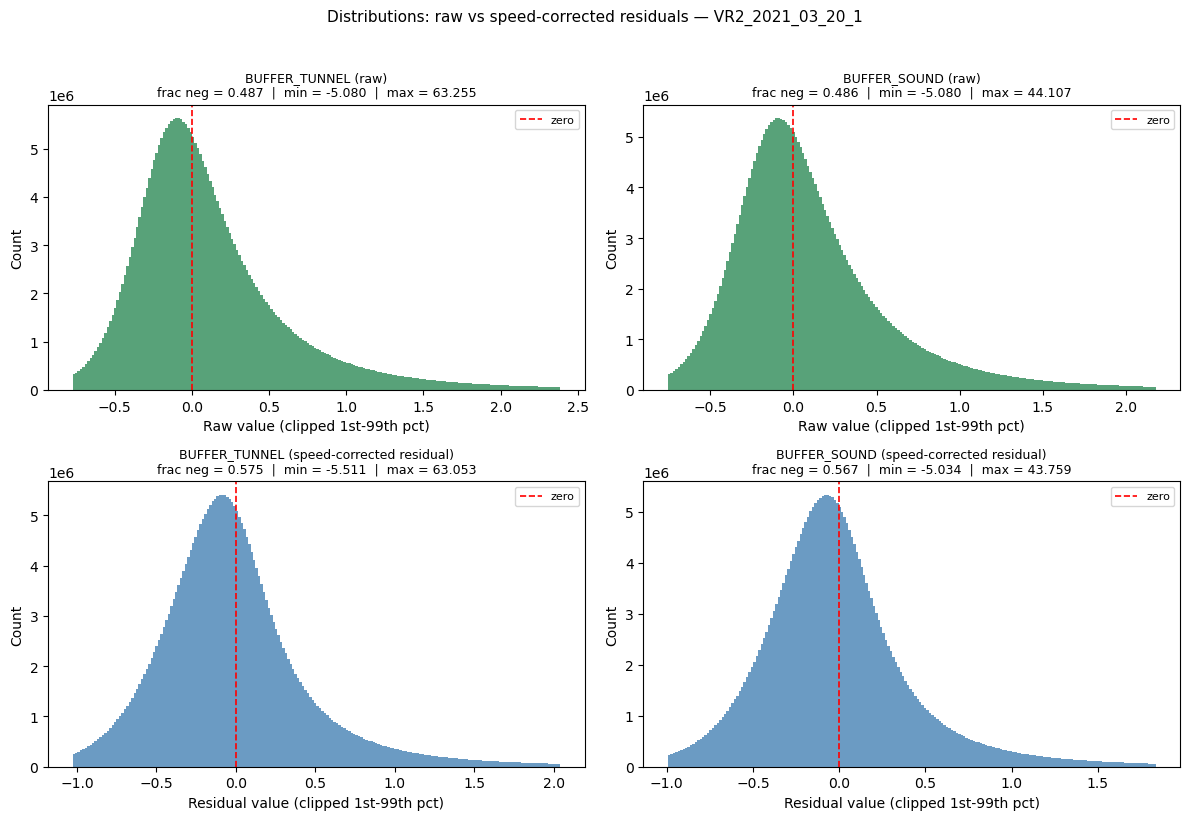


=== Negativity Summary ===

BUFFER_TUNNEL:
  raw: frac_negative = 0.487  |  min = -5.080  |  max = 63.255
  residual: frac_negative = 0.575  |  min = -5.511  |  max = 63.053

BUFFER_SOUND:
  raw: frac_negative = 0.486  |  min = -5.080  |  max = 44.107
  residual: frac_negative = 0.567  |  min = -5.034  |  max = 43.759


In [6]:
# 2x2 grid: raw (pre-speed-correction) vs speed-corrected residuals
names = list(tensors.keys())
if len(names) != 2:
    print(f"Warning: expected 2 tensors for a 2x2 plot, found {len(names)}. Plotting 2x{len(names)}.")

fig, axes = plt.subplots(2, len(names), figsize=(6 * len(names), 8), squeeze=False)
neg_stats = {}  # name -> {'raw': stats_raw, 'residual': stats_resid}


def summarize(X):
    total = X.size
    n_neg = int((X < 0).sum())
    frac_neg = n_neg / total
    return {
        'shape': X.shape,
        'total_entries': total,
        'n_negative': n_neg,
        'frac_negative': frac_neg,
        'min': float(X.min()),
        'max': float(X.max()),
        'mean': float(X.mean()),
        'std': float(X.std()),
        'median': float(np.median(X)),
        'pct_1': float(np.percentile(X, 1)),
        'pct_99': float(np.percentile(X, 99)),
    }


for col, name in enumerate(names):
    X_raw = tensors[name]['raw']
    X_resid = tensors[name]['residual']

    stats_raw = summarize(X_raw)
    stats_resid = summarize(X_resid)
    neg_stats[name] = {'raw': stats_raw, 'residual': stats_resid}

    # Row 0: raw
    ax = axes[0, col]
    flat_raw = X_raw.ravel()
    clip_lo, clip_hi = stats_raw['pct_1'], stats_raw['pct_99']
    ax.hist(
        flat_raw[(flat_raw >= clip_lo) & (flat_raw <= clip_hi)],
        bins=200,
        color='seagreen',
        edgecolor='none',
        alpha=0.8,
    )
    ax.axvline(0, color='red', ls='--', lw=1.2, label='zero')
    ax.set_title(
        f"{name} (raw)\nfrac neg = {stats_raw['frac_negative']:.3f}  |  min = {stats_raw['min']:.3f}  |  max = {stats_raw['max']:.3f}",
        fontsize=9,
    )
    ax.set_xlabel('Raw value (clipped 1st-99th pct)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)

    # Row 1: speed-corrected residuals
    ax = axes[1, col]
    flat_resid = X_resid.ravel()
    clip_lo, clip_hi = stats_resid['pct_1'], stats_resid['pct_99']
    ax.hist(
        flat_resid[(flat_resid >= clip_lo) & (flat_resid <= clip_hi)],
        bins=200,
        color='steelblue',
        edgecolor='none',
        alpha=0.8,
    )
    ax.axvline(0, color='red', ls='--', lw=1.2, label='zero')
    ax.set_title(
        f"{name} (speed-corrected residual)\nfrac neg = {stats_resid['frac_negative']:.3f}  |  min = {stats_resid['min']:.3f}  |  max = {stats_resid['max']:.3f}",
        fontsize=9,
    )
    ax.set_xlabel('Residual value (clipped 1st-99th pct)')
    ax.set_ylabel('Count')
    ax.legend(fontsize=8)


plt.suptitle(
    f"Distributions: raw vs speed-corrected residuals — {target_file}",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.show()

print("\n=== Negativity Summary ===")
for name, s in neg_stats.items():
    print(f"\n{name}:")
    for which in ['raw', 'residual']:
        st = s[which]
        print(
            f"  {which}: frac_negative = {st['frac_negative']:.3f}  |  min = {st['min']:.3f}  |  max = {st['max']:.3f}"
        )

## 4. Diagnostic 2 — `ncp_hals` vs `cp_als` reconstruction error

For each alignment, fit both constrained (nonnegative) and unconstrained CP decompositions
across a rank sweep and compare their normalized reconstruction errors.

In [7]:
results = {}

for name, data in tensors.items():
    X_resid = data['residual']
    print(f"\n{'='*60}")
    print(f"Fitting {name}  (shape {X_resid.shape})")
    print(f"{'='*60}")

    print("  [1/2] cp_als on residuals ...")
    ens_cpals = fit_ensemble(X_resid, 'cp_als', RANK_RANGE, REPLICATES)
    obj_cpals = best_objectives(ens_cpals, RANK_RANGE)

    print("  [2/2] ncp_hals on residuals ...")
    ens_ncp = fit_ensemble(X_resid, 'ncp_hals', RANK_RANGE, REPLICATES)
    obj_ncp = best_objectives(ens_ncp, RANK_RANGE)

    results[name] = {
        'obj_cpals': obj_cpals,
        'obj_ncp': obj_ncp,
    }
    print(f"  Done. cp_als best@R{max(RANK_RANGE)} = {obj_cpals[-1]:.4f}, ncp_hals best@R{max(RANK_RANGE)} = {obj_ncp[-1]:.4f}")


Fitting BUFFER_TUNNEL  (shape (81473, 11, 348))
  [1/2] cp_als on residuals ...


Rank-1 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 112.4s


Rank-2 models:  min obj, 0.94;  max obj, 0.94;  time to fit, 233.3s


Rank-3 models:  min obj, 0.91;  max obj, 0.91;  time to fit, 237.8s


Rank-4 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 483.2s


...

  [2/2] ncp_hals on residuals ...


Rank-1 models:  min obj, 0.98;  max obj, 0.98;  time to fit, 36.6s


Rank-2 models:  min obj, 0.98;  max obj, 0.98;  time to fit, 62.6s


Rank-3 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 162.2s


Rank-4 models:  min obj, 0.96;  max obj, 0.97;  time to fit, 125.0s
  Done. cp_als best@R4 = 0.9250, ncp_hals best@R4 = 0.9640


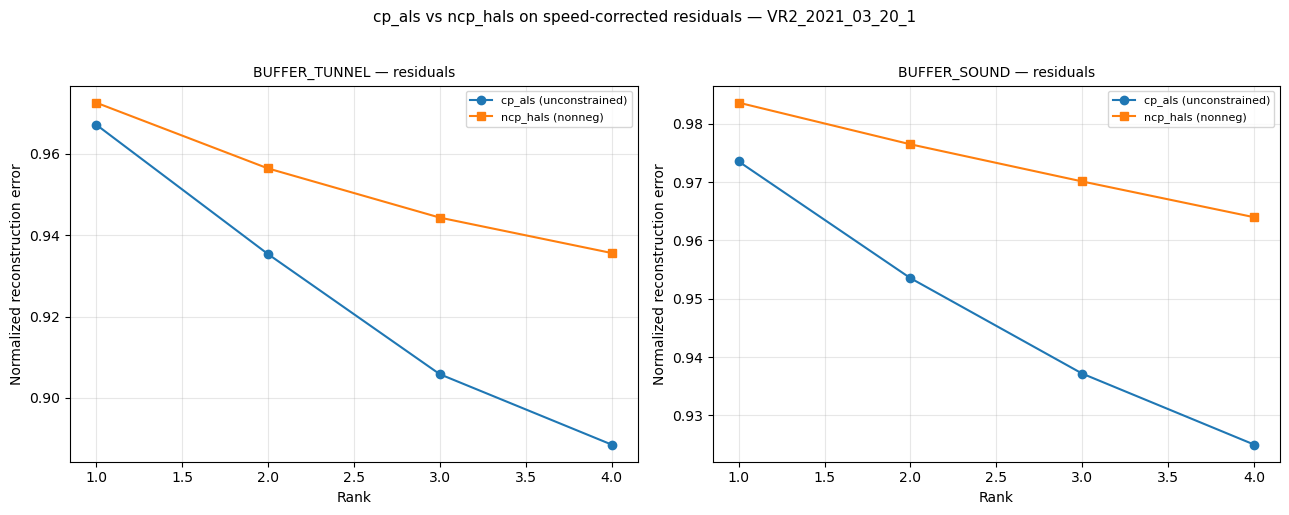

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, results.items()):
    ranks = list(RANK_RANGE)
    ax.plot(ranks, res['obj_cpals'], 'o-', label='cp_als (unconstrained)', color='tab:blue')
    ax.plot(ranks, res['obj_ncp'], 's-', label='ncp_hals (nonneg)', color='tab:orange')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Normalized reconstruction error')
    ax.set_title(f"{name} — residuals", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"cp_als vs ncp_hals on speed-corrected residuals — {target_file}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 5. Diagnostic 3 — `ncp_hals` on residuals vs `ncp_hals` on per-neuron shifted residuals

If each neuron is shifted by subtracting its own minimum value (across all time bins and
trials), nonnegative TCA operates on a fully nonnegative tensor while preserving within-neuron
structure and between-neuron scale. We compare whether this meaningfully improves the nonneg fit.

In [9]:
def shift_tensor_nonneg(tensor):
    """Per-neuron minimum shift to make all values >= 0.

    Each neuron is shifted by subtracting its own minimum value (across all
    time bins and trials).  This preserves within-neuron temporal and trial
    structure as well as between-neuron scale (variance / range) while
    ensuring compatibility with nonnegative TCA (ncp_hals).
    """
    flat = tensor.reshape(tensor.shape[0], -1)
    neuron_mins = flat.min(axis=1, keepdims=True)
    shifted_flat = flat - neuron_mins
    return shifted_flat.reshape(tensor.shape).astype(np.float32)


for name, data in tensors.items():
    X_resid = data['residual']
    X_shifted = shift_tensor_nonneg(X_resid)
    data['shifted'] = X_shifted

    print(f"{name} shifted: min={X_shifted.min():.4f}, max={X_shifted.max():.4f}, "
          f"mean={X_shifted.mean():.4f}, frac_neg={(X_shifted < 0).sum() / X_shifted.size:.6f}")

BUFFER_TUNNEL scaled: min=0.0000, max=1.0000, mean=0.2571, frac_neg=0.000000
BUFFER_SOUND scaled: min=0.0000, max=1.0000, mean=0.2859, frac_neg=0.000000


In [10]:
for name, data in tensors.items():
    X_shifted = data['shifted']
    print(f"\nFitting ncp_hals on per-neuron shifted {name} ...")
    ens_ncp_shifted = fit_ensemble(X_shifted, 'ncp_hals', RANK_RANGE, REPLICATES)
    obj_ncp_shifted = best_objectives(ens_ncp_shifted, RANK_RANGE)
    results[name]['obj_ncp_shifted'] = obj_ncp_shifted
    print(f"  ncp_hals on shifted best@R{max(RANK_RANGE)} = {obj_ncp_shifted[-1]:.4f}")

# --- persist results for later plotting ---
import os, pickle

save_dir = 'artifacts'
os.makedirs(save_dir, exist_ok=True)

target = globals().get('target_file', 'unknown_target')

save_path = os.path.join(save_dir, f'sensitivity_check_{target}.pkl')
payload = {
    'target_file': target,
    'RANK_RANGE': list(RANK_RANGE),
    'neg_stats': neg_stats,
    'results': results,
}

with open(save_path, 'wb') as f:
    pickle.dump(payload, f)

print(f'Saved sensitivity results to: {save_path}')


Fitting ncp_hals on min-max scaled BUFFER_TUNNEL ...


Rank-1 models:  min obj, 0.30;  max obj, 0.30;  time to fit, 12.5s


Rank-2 models:  min obj, 0.29;  max obj, 0.29;  time to fit, 352.0s


Rank-3 models:  min obj, 0.28;  max obj, 0.28;  time to fit, 212.5s


Rank-4 models:  min obj, 0.27;  max obj, 0.28;  time to fit, 195.5s


  ncp_hals on scaled best@R4 = 0.2739

Fitting ncp_hals on min-max scaled BUFFER_SOUND ...


Rank-1 models:  min obj, 0.29;  max obj, 0.29;  time to fit, 12.5s


Rank-2 models:  min obj, 0.28;  max obj, 0.28;  time to fit, 179.1s


Rank-3 models:  min obj, 0.27;  max obj, 0.27;  time to fit, 173.8s


Rank-4 models:  min obj, 0.27;  max obj, 0.27;  time to fit, 157.4s
  ncp_hals on scaled best@R4 = 0.2712
Saved sensitivity results to: artifacts/sensitivity_check_VR2_2021_03_20_1.pkl


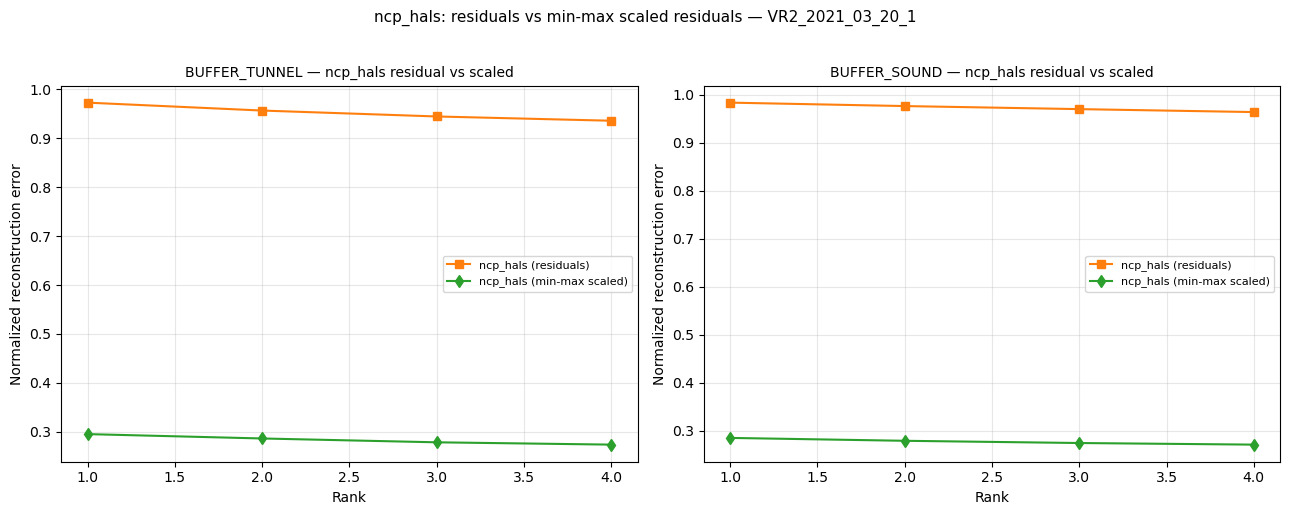

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (name, res) in zip(axes, results.items()):
    ranks = list(RANK_RANGE)
    ax.plot(ranks, res['obj_ncp'], 's-', label='ncp_hals (residuals)', color='tab:orange')
    ax.plot(ranks, res['obj_ncp_shifted'], 'd-', label='ncp_hals (per-neuron shifted)', color='tab:green')
    ax.set_xlabel('Rank')
    ax.set_ylabel('Normalized reconstruction error')
    ax.set_title(f"{name} — ncp_hals residual vs shifted", fontsize=10)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(f"ncp_hals: residuals vs per-neuron shifted residuals — {target_file}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 6. Combined comparison plot

KeyError: 'frac_negative'

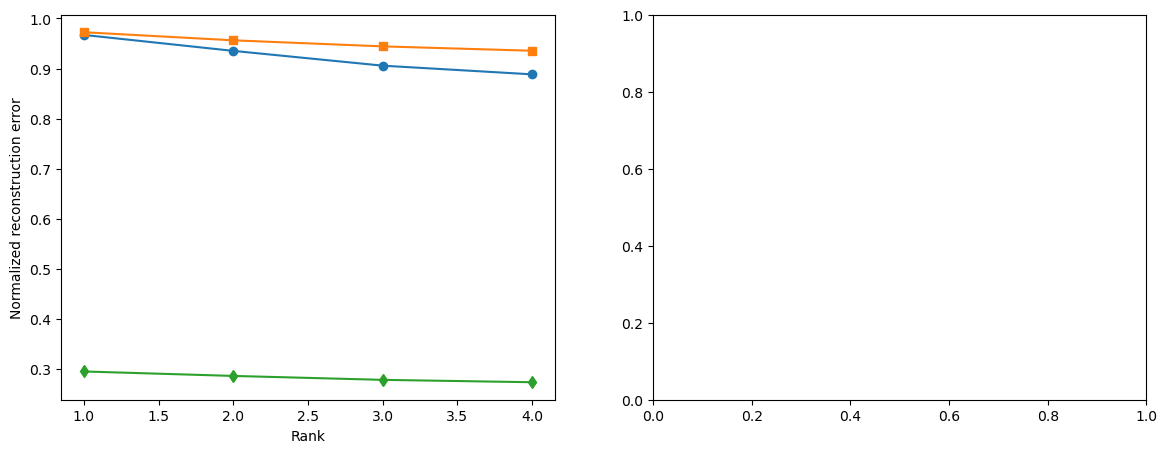

In [14]:
# Reload saved fit results if available (so you can replot after a kernel restart)
import os, pickle
save_path = os.path.join('artifacts', f'sensitivity_check_{target_file}.pkl')
if os.path.exists(save_path):
    with open(save_path, 'rb') as f:
        payload = pickle.load(f)
    results = payload['results']
    neg_stats = payload['neg_stats']
    if 'RANK_RANGE' in payload:
        RANK_RANGE = payload['RANK_RANGE']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, res) in zip(axes, results.items()):
    ranks = list(RANK_RANGE)
    ax.plot(ranks, res['obj_cpals'], 'o-', label='cp_als (residuals)', color='tab:blue', lw=1.5)
    if 'obj_cpals_raw' in res:
        ax.plot(ranks, res['obj_cpals_raw'], 'o--', label='cp_als (raw, no speed corr.)', color='tab:blue', lw=1.5, alpha=0.5)
    ax.plot(ranks, res['obj_ncp'], 's-', label='ncp_hals (residuals)', color='tab:orange', lw=1.5)
    ax.plot(ranks, res['obj_ncp_shifted'], 'd-', label='ncp_hals (per-neuron shifted)', color='tab:green', lw=1.5)
    if 'obj_ncp_raw' in res:
        ax.plot(ranks, res['obj_ncp_raw'], '^-', label='ncp_hals (raw, no speed corr.)', color='tab:red', lw=1.5)

    ax.set_xlabel('Rank')
    ax.set_ylabel('Normalized reconstruction error')
    frac = neg_stats[name]['frac_negative']
    ax.set_title(f"{name}  (frac negative = {frac:.3f})", fontsize=10)
    ax.legend(fontsize=7.5, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Full comparison — {globals().get('target_file', 'unknown_target')}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## 7. Automated diagnosis and recommendation

In [ ]:
RELATIVE_GAP_THRESHOLD = 0.10
FRAC_NEG_THRESHOLD = 0.50

print("=" * 72)
print("SENSITIVITY CHECK — AUTOMATED DIAGNOSIS")
print(f"Target: {target_file}")
print(f"Speed correction: {SPEED_CORRECT_BY}")
print(f"Rank range: {list(RANK_RANGE)}, Replicates: {REPLICATES}")
print("=" * 72)

all_ok = True

for name in tensors:
    res = results[name]
    ns = neg_stats[name]

    print(f"\n--- {name} ---")
    print(f"  Tensor shape:        {ns['shape']}")
    print(f"  Fraction negative:   {ns['frac_negative']:.4f} ({ns['n_negative']:,} / {ns['total_entries']:,})")
    print(f"  Value range:         [{ns['min']:.4f}, {ns['max']:.4f}]")
    print(f"  Mean / Std:          {ns['mean']:.4f} / {ns['std']:.4f}")
    print(f"  1st / 99th pct:      {ns['pct_1']:.4f} / {ns['pct_99']:.4f}")

    obj_cp = res['obj_cpals']
    obj_ncp = res['obj_ncp']
    obj_ncp_s = res['obj_ncp_shifted']

    print(f"\n  Reconstruction error (best, at max rank {max(RANK_RANGE)}):")
    print(f"    cp_als  (unconstrained, residuals):    {obj_cp[-1]:.4f}")
    print(f"    ncp_hals (nonneg, residuals):           {obj_ncp[-1]:.4f}")
    print(f"    ncp_hals (nonneg, per-neuron shifted):  {obj_ncp_s[-1]:.4f}")

    gap_ncp_vs_cp = (obj_ncp[-1] - obj_cp[-1]) / (obj_cp[-1] + 1e-12)
    gap_ncp_vs_shifted = (obj_ncp[-1] - obj_ncp_s[-1]) / (obj_ncp_s[-1] + 1e-12)

    print(f"\n  Relative gap (ncp_hals residual vs cp_als residual): {gap_ncp_vs_cp:+.4f} ({gap_ncp_vs_cp*100:+.1f}%)")
    print(f"  Relative gap (ncp_hals residual vs ncp_hals shifted): {gap_ncp_vs_shifted:+.4f} ({gap_ncp_vs_shifted*100:+.1f}%)")

    # Diagnosis logic
    issues = []

    if gap_ncp_vs_cp > RELATIVE_GAP_THRESHOLD:
        issues.append(
            f"ncp_hals is {gap_ncp_vs_cp*100:.1f}% worse than cp_als (threshold: {RELATIVE_GAP_THRESHOLD*100:.0f}%). "
            f"Nonnegativity constraint is losing substantial model capacity on these residuals."
        )

    if ns['frac_negative'] > FRAC_NEG_THRESHOLD:
        issues.append(
            f"Fraction of negative entries ({ns['frac_negative']:.2%}) exceeds {FRAC_NEG_THRESHOLD:.0%}. "
            f"The residual tensor is dominated by negative values."
        )

    if abs(gap_ncp_vs_shifted) > RELATIVE_GAP_THRESHOLD:
        issues.append(
            f"Per-neuron shifting changes ncp_hals error by {gap_ncp_vs_shifted*100:+.1f}% (threshold: "
            f"{RELATIVE_GAP_THRESHOLD*100:.0f}%). Shifting materially affects the decomposition."
        )

    print(f"\n  VERDICT for {name}:")
    if not issues:
        print(f"    OK — ncp_hals on residuals is comparable to cp_als and shifting has modest effect.")
        print(f"    -> Negative residuals are not materially harming the nonnegative decomposition.")
        print(f"    -> Safe to proceed with ncp_hals on speed-corrected residuals as-is.")
    else:
        all_ok = False
        for issue in issues:
            print(f"    WARNING: {issue}")

print("\n" + "=" * 72)
print("OVERALL RECOMMENDATION")
print("=" * 72)

if all_ok:
    print(
        "\nAll alignments pass the sensitivity check.\n"
        "ncp_hals on speed-corrected residuals produces reconstruction errors\n"
        "comparable to unconstrained cp_als, and per-neuron shifting has little effect.\n"
        "\n"
        "-> PROCEED with ncp_hals on residuals (current Batch_TCA_Pipeline setup).\n"
        "   No additional shifting/scaling/rectification is needed."
    )
else:
    print(
        "\nOne or more alignments show a meaningful gap between ncp_hals and cp_als,\n"
        "or the fraction of negative entries is very large.\n"
        "\n"
        "Consider the following options (in order of preference):\n"
        "\n"
        "  Option A: Switch to cp_als (unconstrained CP) for residual tensors.\n"
        "    Pro: Full model capacity; signed factors capture negative structure.\n"
        "    Con: Factors are harder to interpret (can be negative); less unique solutions.\n"
        "\n"
        "  Option B: Use per-neuron minimum shift before ncp_hals.\n"
        "    Pro: Keeps nonnegative constraints; preserves between-neuron scale.\n"
        "    Con: Neuron-specific shift may introduce artefactual structure\n"
        "         that varies across sessions/mice; residuals lose their 'zero-mean' property.\n"
        "\n"
        "  Option C: Skip speed correction and run ncp_hals on raw (nonnegative) activity.\n"
        "    Pro: Inherently nonneg data; straightforward.\n"
        "    Con: Speed confound remains in the decomposition.\n"
        "\n"
        "Review the plots above to decide. If the gap is modest (<15%) and the\n"
        "negative fraction is <50%, ncp_hals on residuals is likely acceptable—\n"
        "just be aware that the model cannot represent negative structure."
    )

SENSITIVITY CHECK — AUTOMATED DIAGNOSIS
Target: VR2_2021_03_20_1
Speed correction: simple
Rank range: [1, 2, 3, 4], Replicates: 3

--- BUFFER_TUNNEL ---
  Tensor shape:        (81473, 11, 348)
  Fraction negative:   0.5753 (179,409,212 / 311,878,644)
  Value range:         [-5.5108, 63.0532]
  Mean / Std:          0.0000 / 0.5742
  1st / 99th pct:      -1.0277 / 2.0397

  Reconstruction error (best, at max rank 4):
    cp_als  (unconstrained, residuals):    0.8875
    ncp_hals (nonneg, residuals):           0.9356
    ncp_hals (nonneg, min-max scaled):      0.2739

  Relative gap (ncp_hals residual vs cp_als residual): +0.0543 (+5.4%)
  Relative gap (ncp_hals residual vs ncp_hals scaled):  +2.4156 (+241.6%)

  VERDICT for BUFFER_TUNNEL:

--- BUFFER_SOUND ---
  Tensor shape:        (81473, 11, 348)
  Fraction negative:   0.5666 (176,700,412 / 311,878,644)
  Value range:         [-5.0337, 43.7587]
  Mean / Std:          -0.0000 / 0.5210
  1st / 99th pct:      -0.9930 / 1.8353

  Reconstr

## 8. Raw (nonneg) tensor baseline — ncp_hals on raw activity (no speed correction)

For reference: how does ncp_hals perform on the raw (pre-speed-correction) tensor,
which is natively nonnegative? This gives a ceiling for how well nonneg TCA can work
when the input is genuinely nonnegative.


BUFFER_TUNNEL raw tensor: min=-5.0796, max=63.2552, frac_neg=0.4874
  NOTE: Raw tensor has negative values (48.74%). This comes from the SVD reconstruction, not from speed correction.
  Fitting ncp_hals on raw tensor ...

BUFFER_SOUND raw tensor: min=-5.0796, max=44.1074, frac_neg=0.4862
  NOTE: Raw tensor has negative values (48.62%). This comes from the SVD reconstruction, not from speed correction.
  Fitting ncp_hals on raw tensor ...


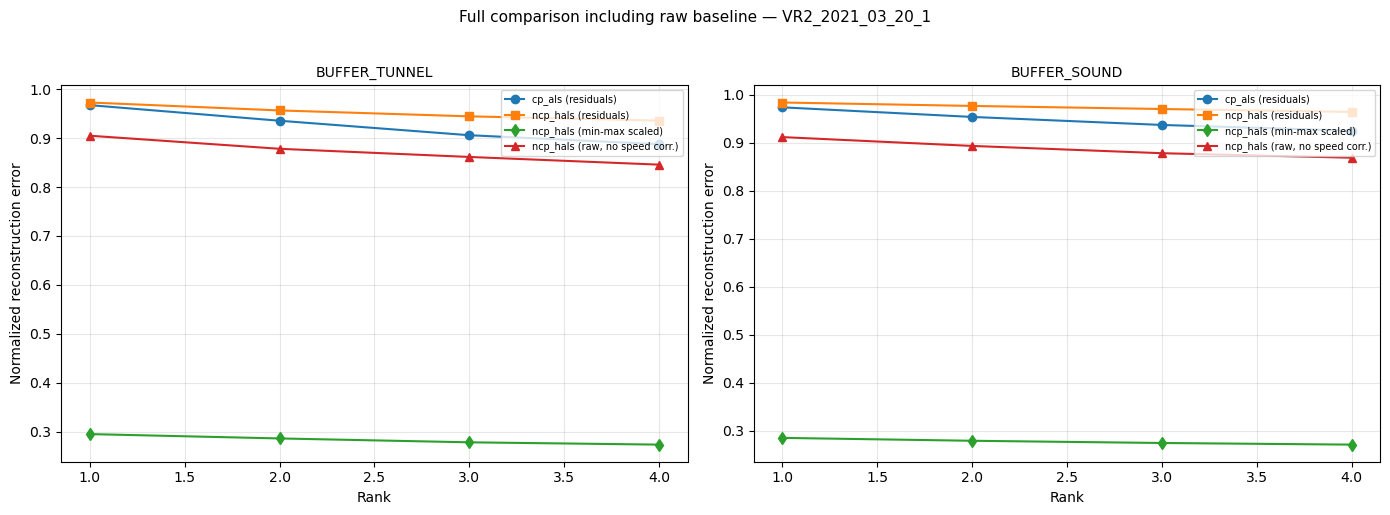

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, data) in zip(axes, tensors.items()):
    X_raw = data['raw']
    raw_has_neg = (X_raw < 0).any()
    frac_raw_neg = float((X_raw < 0).sum()) / X_raw.size

    print(f"\n{name} raw tensor: min={X_raw.min():.4f}, max={X_raw.max():.4f}, "
          f"frac_neg={frac_raw_neg:.4f}")

    if raw_has_neg:
        print(f"  NOTE: Raw tensor has negative values ({frac_raw_neg:.2%}). "
              f"This comes from the SVD reconstruction, not from speed correction.")

    print(f"  Fitting cp_als on raw tensor ...")
    ens_cpals_raw = fit_ensemble(X_raw, 'cp_als', RANK_RANGE, REPLICATES)
    obj_cpals_raw = best_objectives(ens_cpals_raw, RANK_RANGE)
    results[name]['obj_cpals_raw'] = obj_cpals_raw

    print(f"  Fitting ncp_hals on raw tensor ...")
    ens_ncp_raw = fit_ensemble(X_raw, 'ncp_hals', RANK_RANGE, REPLICATES)
    obj_ncp_raw = best_objectives(ens_ncp_raw, RANK_RANGE)
    results[name]['obj_ncp_raw'] = obj_ncp_raw

    ranks = list(RANK_RANGE)
    res = results[name]
    ax.plot(ranks, res['obj_cpals'], 'o-', label='cp_als (residuals)', color='tab:blue', lw=1.5)
    ax.plot(ranks, res['obj_cpals_raw'], 'o--', label='cp_als (raw, no speed corr.)', color='tab:blue', lw=1.5, alpha=0.5)
    ax.plot(ranks, res['obj_ncp'], 's-', label='ncp_hals (residuals)', color='tab:orange', lw=1.5)
    ax.plot(ranks, res['obj_ncp_shifted'], 'd-', label='ncp_hals (per-neuron shifted)', color='tab:green', lw=1.5)
    ax.plot(ranks, res['obj_ncp_raw'], '^-', label='ncp_hals (raw, no speed corr.)', color='tab:red', lw=1.5)
    ax.set_xlabel('Rank')
    ax.set_ylabel('Normalized reconstruction error')
    ax.set_title(f"{name}", fontsize=10)
    ax.legend(fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.3)

plt.suptitle(f"Full comparison including raw baseline — {globals().get('target_file', 'unknown_target')}", fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# Persist updated results (now includes raw baselines for both cp_als and ncp_hals)
target = globals().get('target_file', 'unknown_target')
save_path = os.path.join('artifacts', f'sensitivity_check_{target}.pkl')
with open(save_path, 'wb') as f:
    pickle.dump(dict(target_file=target, RANK_RANGE=list(RANK_RANGE),
                     neg_stats=neg_stats, results=results), f)
print(f"Artifact updated at {save_path}")

## 9. Numeric summary table

In [ ]:
rows = []
for name in tensors:
    res = results[name]
    ns = neg_stats[name]
    for r_idx, r in enumerate(RANK_RANGE):
        rows.append({
            'alignment': name,
            'rank': r,
            'frac_negative': ns['frac_negative'],
            'cp_als_resid': res['obj_cpals'][r_idx],
            'ncp_hals_resid': res['obj_ncp'][r_idx],
            'ncp_hals_shifted': res['obj_ncp_shifted'][r_idx],
            'ncp_hals_raw': res['obj_ncp_raw'][r_idx],
        })

summary_df = pd.DataFrame(rows)
summary_df['gap_ncp_vs_cp_%'] = (
    (summary_df['ncp_hals_resid'] - summary_df['cp_als_resid']) / summary_df['cp_als_resid'] * 100
)

with pd.option_context('display.float_format', '{:.4f}'.format, 'display.max_rows', None):
    display(summary_df)

,alignment,rank,frac_negative,cp_als_resid,ncp_hals_resid,ncp_hals_scaled,ncp_hals_raw,gap_ncp_vs_cp_%
0,BUFFER_TUNNEL,1,0.5753,0.9672,0.9726,0.2954,0.9048,0.5582
1,BUFFER_TUNNEL,2,0.5753,0.9353,0.9564,0.2865,0.8781,2.2489
2,BUFFER_TUNNEL,3,0.5753,0.9058,0.9443,0.2786,0.8614,4.2548
3,BUFFER_TUNNEL,4,0.5753,0.8875,0.9356,0.2739,0.8457,5.4278
4,BUFFER_SOUND,1,0.5666,0.9736,0.9836,0.2852,0.9116,1.0342
5,BUFFER_SOUND,2,0.5666,0.9536,0.9765,0.2792,0.8932,2.4022
6,BUFFER_SOUND,3,0.5666,0.9369,0.9701,0.2746,0.8780,3.5419
7,BUFFER_SOUND,4,0.5666,0.9249,0.9640,0.2712,0.8686,4.2296
